<img src ='https://i.ibb.co/LRmvR3M/PSS3-E4.png'>
<center><h1> Tabular Classification with Credit Card Fraud Datasset </h1></center>

> 📌 **The goal of this competition is to identify fraudulent credit card transactions.**.<br>
> 📌 **Submissions are evaluated on area under the ROC curve between the predicted probability and the observed target.** <br>
> 📌 **The dataset for this competition was generated from a deep learning model trained on the [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud).**

# Table of Content


1. [IMPORTS](#IMPORTS)
1. [FIRST LOOK AT THE DATA](#FIRST-LOOK-AT-THE-DATA)
1. [VISUALISATION](#VISUALISATION)

# <center><div style="background-color:#FFE4B5;font-size:125%;text-align:center;color:#8B0000;letter-spacing:2px;font-family:bold;border-radius:10px"><u>IMPORTS</u></div></center>

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
data_dir = Path('/kaggle/input/playground-series-s3e4')

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_train = pd.read_csv(data_dir/'train.csv')
df_test = pd.read_csv(data_dir/'test.csv')
submission = pd.read_csv(data_dir/'sample_submission.csv')

In [3]:
original = pd.read_csv('/kaggle/input/creditcardfraud/creditcard.csv')

# <center><div style="background-color:#FFE4B5;font-size:125%;text-align:center;color:#8B0000;letter-spacing:2px;font-family:bold;border-radius:10px"><u>FIRST LOOK AT THE DATA</u></div></center>

#### <b>Column details</b>
* `id` : Unique identifier
* `Time` :  Seconds elapsed between each transaction and the first transaction in the dataset
* `V1 - V28` : Numerical input variables which are the result of a PCA transformation.
*  `Amount` : Transaction amount
*  `Class` : Response variable that takes either 1(fraud) or 0

<h3> Observation </h3>

> 📌**Train data contains 219129 rows and 32 columns.**<br>
> 📌**Test data contains 146087 rows.**<br>
> 📌**The dataset has no missing values.**<br>
> 📌**Duplicates are not found in the dataset.**<br>

In [4]:
df_train.head()

,id,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,0.0,2.074329,-0.129425,-1.137418,0.412846,-0.192638,-1.210144,0.110697,-0.263477,0.742144,0.108782,-1.070243,-0.234910,-1.099360,0.502467,0.169318,0.065688,-0.306957,-0.323800,0.103348,-0.292969,-0.334701,-0.887840,0.336701,-0.110835,-0.291459,0.207733,-0.076576,-0.059577,1.98,0
1,1,0.0,1.998827,-1.250891,-0.520969,-0.894539,-1.122528,-0.270866,-1.029289,0.050198,-0.109948,0.908773,0.836798,-0.056580,-0.120990,-0.144028,-0.039582,1.653057,-0.253599,-0.814354,0.716784,0.065717,0.054848,-0.038367,0.133518,-0.461928,-0.465491,-0.464655,-0.009413,-0.038238,84.00,0
2,2,0.0,0.091535,1.004517,-0.223445,-0.435249,0.667548,-0.988351,0.948146,-0.084789,-0.042027,-0.818383,-0.376512,-0.226546,-0.552869,-0.886466,-0.180890,0.230286,0.590579,-0.321590,-0.433959,-0.021375,-0.326725,-0.803736,0.154495,0.951233,-0.506919,0.085046,0.224458,0.087356,2.69,0
3,3,0.0,1.979649,-0.184949,-1.064206,0.120125,-0.215238,-0.648829,-0.087826,-0.035367,0.885838,-0.007527,0.637441,0.676960,-1.504823,0.554039,-0.824356,-0.527267,-0.095838,-0.312519,0.642659,-0.340089,-0.095514,-0.079792,0.167701,-0.042939,0.000799,-0.096148,-0.057780,-0.073839,1.00,0
4,4,0.0,1.025898,-0.171827,1.203717,1.243900,-0.636572,1.099074,-0.938651,0.569239,0.692665,-0.097495,1.338869,1.391399,-0.128167,-0.081836,0.100548,-0.338937,0.090864,-0.423645,-0.731939,-0.203628,0.099157,0.608908,0.027901,-0.262813,0.257834,-0.252829,0.108338,0.021051,1.00,0


In [5]:
df_train.tail()

,id,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
219124,219124,120580.0,1.891079,-1.272908,-3.783908,-1.388939,2.012789,2.666080,0.151740,0.401934,-1.102824,0.858158,-0.280639,0.007976,-0.124950,0.914374,-0.073169,-2.309929,-0.041423,1.190526,-0.281848,-0.195703,-0.181369,-0.456538,-0.069571,0.756765,0.244479,-0.147566,-0.054725,-0.044588,198.65,0
219125,219125,120580.0,0.139724,0.948649,-2.913655,-2.184829,1.883716,-1.056824,1.725624,0.018089,-0.823494,-0.257933,-0.457534,0.516146,-0.071240,1.310799,-1.892909,-0.318780,-0.917395,0.098397,-0.195558,-0.116538,0.491469,1.478823,-0.085398,-0.091409,-1.053488,0.467570,0.358918,0.294735,24.00,0
219126,219126,120580.0,2.058343,-0.038993,-1.928553,0.330117,0.270127,-0.735664,-0.173878,0.144823,0.849289,-0.136498,0.179926,-1.769641,-3.937694,0.031346,0.028100,0.883566,0.391801,1.007789,0.303376,-0.384830,-0.306640,-0.965783,0.307799,-0.021434,-0.343989,0.181065,-0.098387,-0.044064,1.79,0
219127,219127,120580.0,2.079227,-2.162389,-1.785833,-2.804889,0.552845,4.038013,-2.155900,1.023785,-0.865242,1.536193,-0.058879,-0.885949,-0.254718,-0.425730,0.665556,-0.336634,0.301966,0.391249,0.037770,-0.190984,0.109909,0.590401,0.286621,0.675660,-0.510736,-0.090044,0.056749,-0.017126,88.00,0
219128,219128,120580.0,-0.431758,1.299171,-0.571602,-1.161499,1.141765,-1.258871,1.701553,-0.454580,-0.556978,-0.049454,1.374548,1.172926,0.722704,0.525669,-0.926260,-0.379812,-0.640176,-0.161739,0.034470,0.058133,0.225629,0.988442,-0.224609,0.082977,-0.335529,0.042237,0.304965,0.240049,3.78,0


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219129 entries, 0 to 219128
Data columns (total 32 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      219129 non-null  int64  
 1   Time    219129 non-null  float64
 2   V1      219129 non-null  float64
 3   V2      219129 non-null  float64
 4   V3      219129 non-null  float64
 5   V4      219129 non-null  float64
 6   V5      219129 non-null  float64
 7   V6      219129 non-null  float64
 8   V7      219129 non-null  float64
 9   V8      219129 non-null  float64
 10  V9      219129 non-null  float64
 11  V10     219129 non-null  float64
 12  V11     219129 non-null  float64
 13  V12     219129 non-null  float64
 14  V13     219129 non-null  float64
 15  V14     219129 non-null  float64
 16  V15     219129 non-null  float64
 17  V16     219129 non-null  float64
 18  V17     219129 non-null  float64
 19  V18     219129 non-null  float64
 20  V19     219129 non-null  float64
 21  V20     21

In [7]:
df_test.head()

,id,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,219129,120580.0,2.115519,-0.691809,-1.305514,-0.685655,-0.641265,-0.764784,-0.924262,-0.023030,-0.230126,0.220610,1.058325,-0.723363,-0.619241,-2.243711,-0.271429,2.007845,1.213534,0.282344,0.579121,0.067367,0.241708,0.682524,0.037769,-0.546859,-0.123055,-0.084889,0.004720,-0.021944,29.95
1,219130,120580.0,1.743525,-1.681429,-0.547387,-1.061113,-0.695825,2.458824,-1.632859,1.073529,1.068183,0.483337,0.274519,-0.346514,-0.409519,-0.564673,-0.143855,1.334855,0.160901,-0.087356,-0.066264,0.441788,0.543278,1.294571,0.309541,3.703925,-0.242579,0.068708,0.002629,0.064690,163.50
2,219131,120580.0,2.205568,-1.571445,-0.238965,-1.662517,-1.652324,-0.054701,-1.682064,0.105613,-1.177858,1.626352,0.601148,-0.041610,0.432748,-0.527684,-0.543665,0.043896,0.058472,0.622667,0.010671,-0.366906,-0.131527,0.086623,0.291375,0.739087,-0.543006,-0.297813,0.043699,-0.037855,16.00
3,219132,120580.0,1.989728,-0.972909,-1.938259,-1.440129,-0.166855,-0.794048,0.252889,-0.399789,2.079398,-1.225592,-0.869368,1.647638,1.138026,-0.258468,-0.361765,-1.253326,0.099479,-0.587702,1.207085,-0.049136,-0.080115,-0.010732,-0.038550,0.656830,0.343470,-0.627529,-0.024338,-0.036143,120.98
4,219133,120580.0,-1.943548,-1.668761,0.363601,-0.977610,2.684779,-2.037681,0.039709,-0.048895,-0.281749,-0.341879,0.471628,0.637604,-0.592416,0.331702,-1.451799,0.096467,-0.853439,-0.462060,-0.267098,0.391627,0.083389,-0.306918,0.247822,-0.391799,-0.790716,-0.025706,0.330758,0.335537,1.98


In [8]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146087 entries, 0 to 146086
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      146087 non-null  int64  
 1   Time    146087 non-null  float64
 2   V1      146087 non-null  float64
 3   V2      146087 non-null  float64
 4   V3      146087 non-null  float64
 5   V4      146087 non-null  float64
 6   V5      146087 non-null  float64
 7   V6      146087 non-null  float64
 8   V7      146087 non-null  float64
 9   V8      146087 non-null  float64
 10  V9      146087 non-null  float64
 11  V10     146087 non-null  float64
 12  V11     146087 non-null  float64
 13  V12     146087 non-null  float64
 14  V13     146087 non-null  float64
 15  V14     146087 non-null  float64
 16  V15     146087 non-null  float64
 17  V16     146087 non-null  float64
 18  V17     146087 non-null  float64
 19  V18     146087 non-null  float64
 20  V19     146087 non-null  float64
 21  V20     14

In [9]:
# checking for duplicates
df_train.duplicated().sum(),df_test.duplicated().sum()

(0, 0)

In [10]:
print(f'Shape of train data : {df_train.shape}')
print(f'Shape of test data : {df_test.shape}')

Shape of train data : (219129, 32)
Shape of test data : (146087, 31)


In [11]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,219129.0,109564.000000,63257.237906,0.000000,54782.000000,109564.000000,164346.000000,219128.000000
Time,219129.0,62377.415376,25620.348569,0.000000,47933.000000,63189.000000,77519.000000,120580.000000
V1,219129.0,0.096008,1.395425,-29.807725,-0.846135,0.385913,1.190661,2.430494
V2,219129.0,0.048345,1.159805,-44.247914,-0.573728,0.046937,0.814145,16.068473
V3,219129.0,0.592102,1.132884,-19.722872,-0.027154,0.735895,1.306110,6.145578
V4,219129.0,0.069273,1.253125,-5.263650,-0.769256,0.064856,0.919353,12.547997
V5,219129.0,-0.161555,1.069530,-37.591259,-0.847346,-0.229929,0.356856,34.581260
V6,219129.0,0.133688,1.202411,-25.659750,-0.631835,-0.087778,0.482388,16.233967
V7,219129.0,-0.128224,0.817207,-31.179799,-0.646730,-0.098970,0.385567,39.824099
V8,219129.0,0.149534,0.716212,-28.903442,-0.095948,0.111219,0.390976,18.270586


In [12]:
df_test.describe().T

,count,mean,std,min,25%,50%,75%,max
id,146087.0,292172.000000,42171.828725,219129.000000,255650.500000,292172.000000,328693.500000,365215.000000
Time,146087.0,144637.928166,14258.025396,120580.000000,132698.000000,144493.000000,156140.000000,172790.000000
V1,146087.0,0.512929,1.628455,-34.755944,-0.679988,0.285798,1.974015,2.452901
V2,146087.0,-0.013098,1.247749,-37.803827,-0.715885,0.009058,0.827420,12.390128
V3,146087.0,-0.697478,1.292522,-18.934952,-1.619268,-0.719060,0.073874,4.492640
V4,146087.0,-0.273258,1.365752,-5.497560,-1.021205,-0.482945,0.369725,11.232928
V5,146087.0,0.321856,1.146215,-25.639591,-0.418547,0.306851,0.955997,24.352818
V6,146087.0,-0.050204,1.332880,-14.133040,-0.891441,-0.372813,0.302724,16.596635
V7,146087.0,0.073419,0.946681,-18.715915,-0.570042,0.118545,0.734503,27.023955
V8,146087.0,0.043803,0.749513,-26.926164,-0.231824,0.014979,0.296969,12.098322


In [13]:
submission.head()

,id,Class
0,219129,0.5
1,219130,0.5
2,219131,0.5
3,219132,0.5
4,219133,0.5


In [14]:
# Dropping id column from the data set
df_train.drop('id',axis=1, inplace=True)
df_test.drop('id',axis=1, inplace=True)

# <center><div style="background-color:#FFE4B5;font-size:125%;text-align:center;color:#8B0000;letter-spacing:2px;font-family:bold;border-radius:10px"><u>VISUALISATION</u></div></center>
#  <span style="font-size:25px;color:#8B0000;letter-spacing:3px;font-family:bold"><u>Target variable</u></span>
<h3> Observation</h3>

> 📌 Class has high imbalance. Only 0.21% of data is classified as fradulent.

0    99.79
1     0.21
Name: Class, dtype: float64

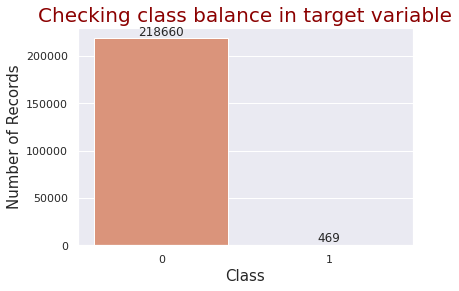

In [15]:
sns.set_theme(palette='flare')

ax = sns.countplot(data = df_train,x='Class');
ax.bar_label(ax.containers[0])
plt.title('Checking class balance in target variable',loc='center',fontsize=20,color='#8B0000');
plt.xlabel('Class',fontsize=15);
plt.ylabel('Number of Records',fontsize=15);


round(df_train.Class.value_counts(normalize=True)*100,2)

#  <span style="font-size:25px;color:#8B0000;letter-spacing:3px;font-family:bold"><u>Time</u></span>

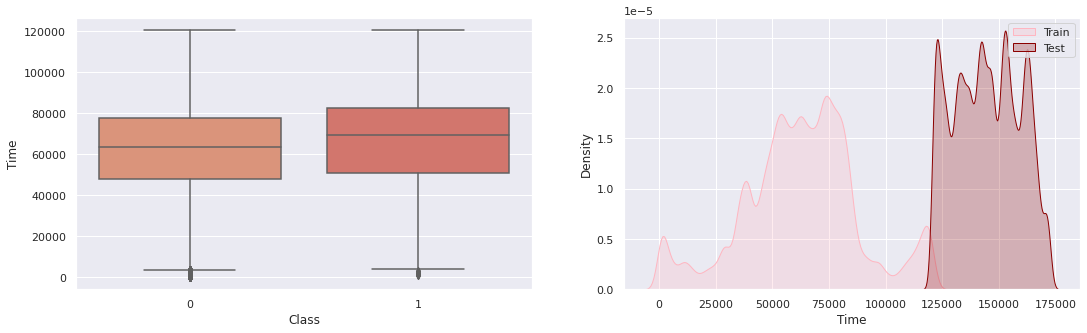

In [16]:
fig, axes = plt.subplots(1,2,figsize=(18,5))
sns.boxplot(ax=axes[0],x='Class',y='Time',data=df_train);
f1 = sns.kdeplot(df_train['Time'], shade=True, color="#FFB6C1",ax=axes[1], label="Train",fill=True);
f1 = sns.kdeplot(df_test['Time'], shade=True,color = '#8B0000',ax=axes[1], label="Test",fill=True);
f1.legend();

#  <span style="font-size:25px;color:#8B0000;letter-spacing:3px;font-family:bold"><u>Amount</u></span>

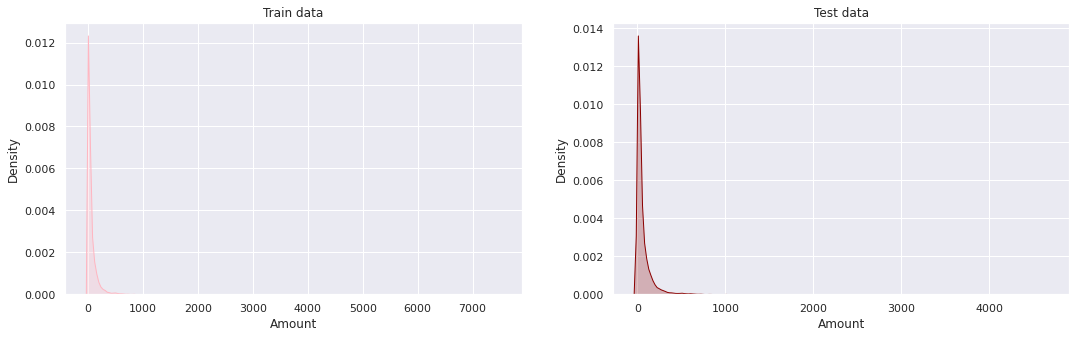

In [17]:
fig, axes = plt.subplots(1,2,figsize=(18,5))
sns.kdeplot(df_train['Amount'], ax=axes[0],shade=True, color="#FFB6C1",fill=True).set(title='Train data');
sns.kdeplot(df_test['Amount'], ax=axes[1],shade=True, color='#8B0000',fill=True).set(title='Test data');

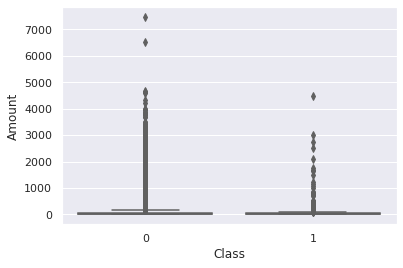

In [18]:
sns.boxplot(x='Class',y='Amount',data=df_train);

#  <span style="font-size:25px;color:#8B0000;letter-spacing:3px;font-family:bold"><u>V1 - V28</u></span>

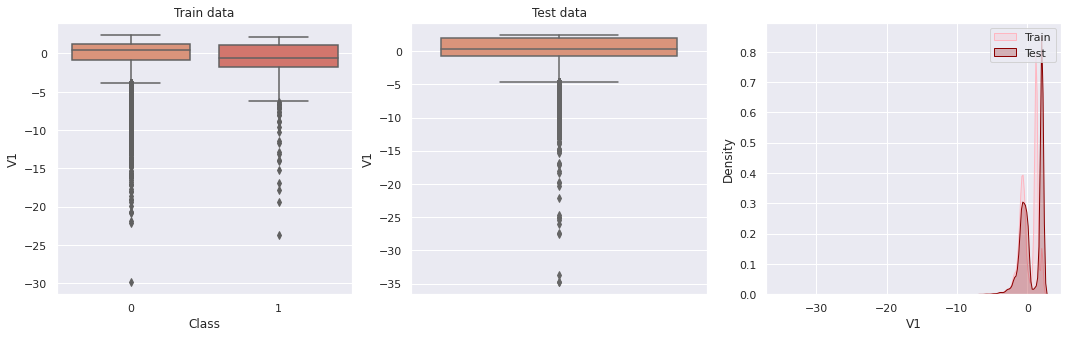

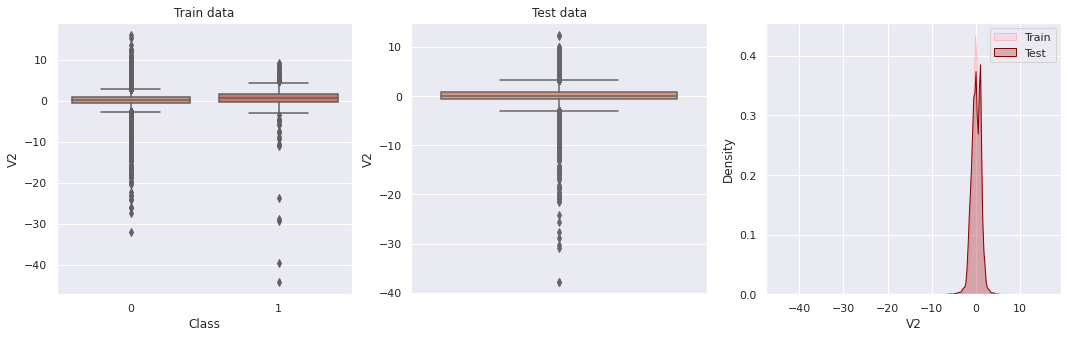

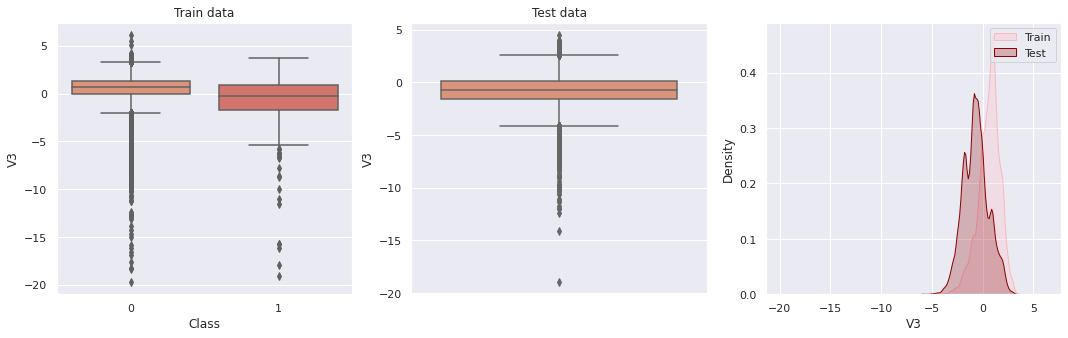

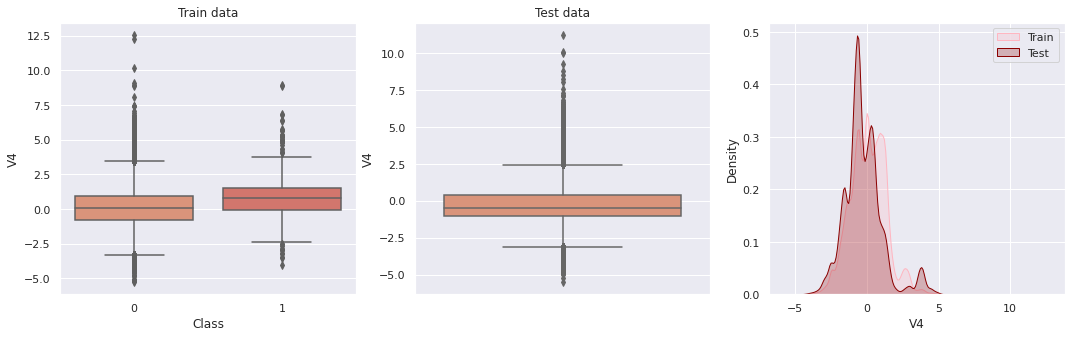

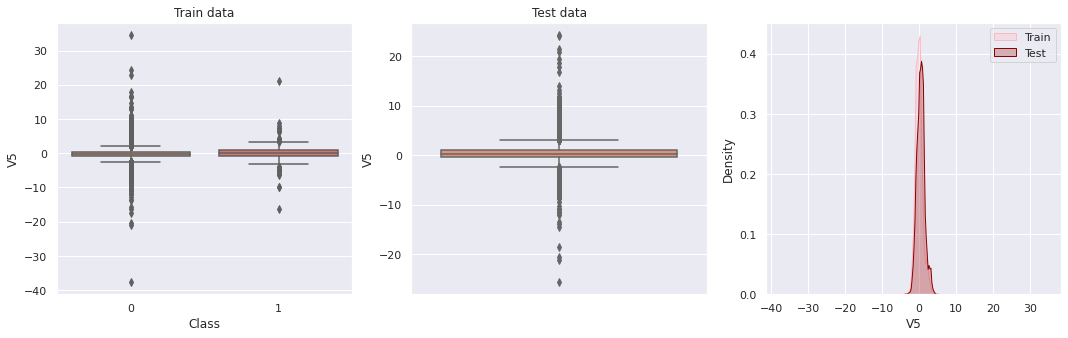

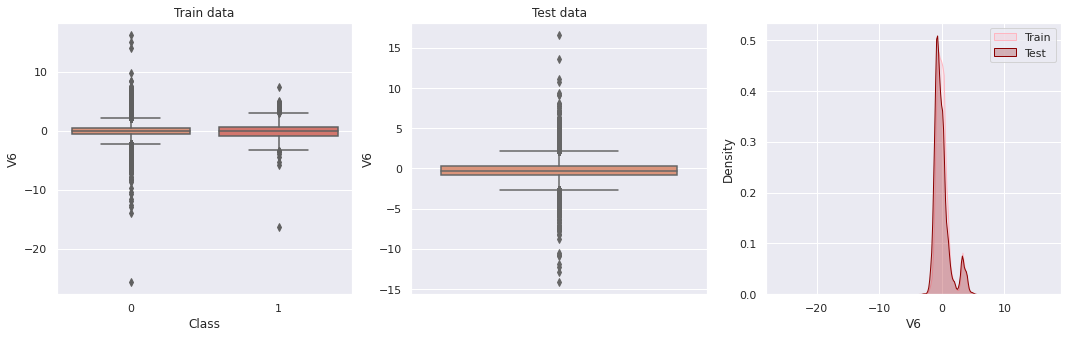

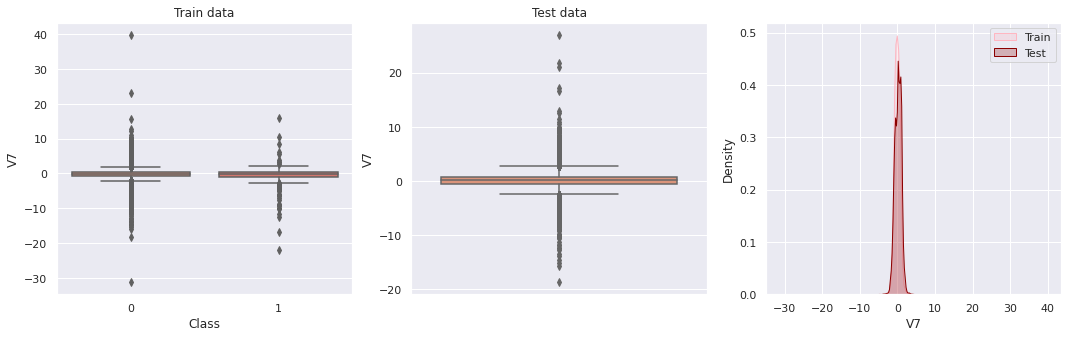

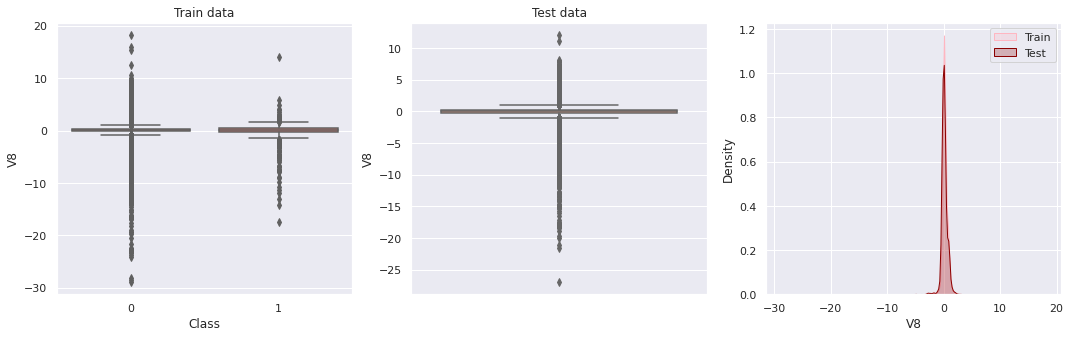

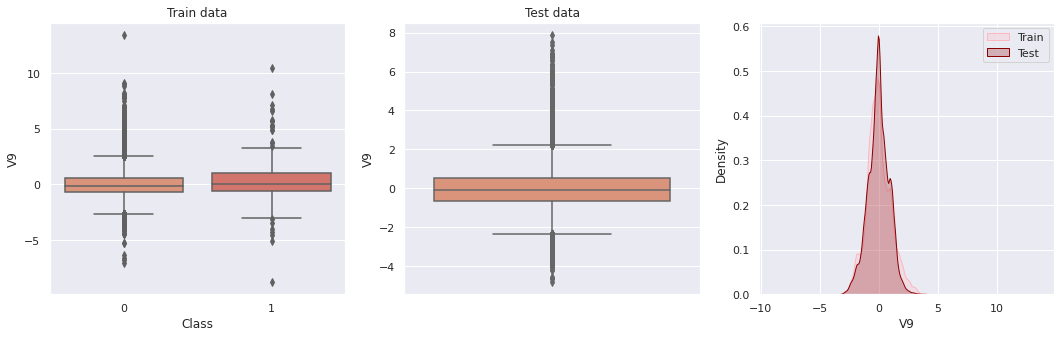

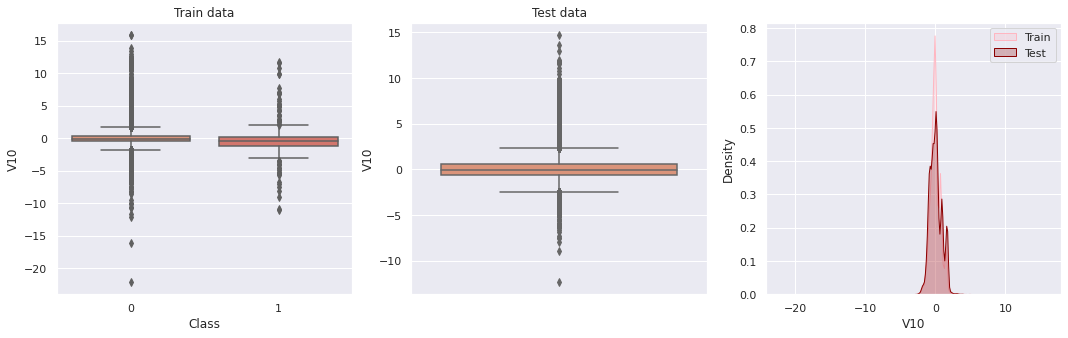

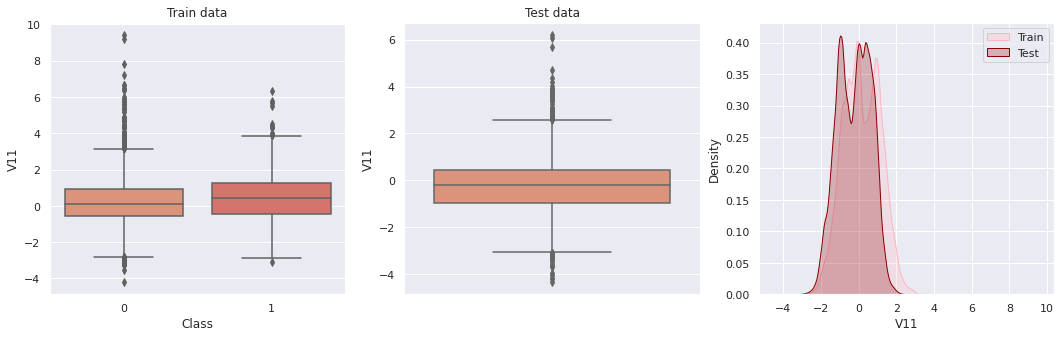

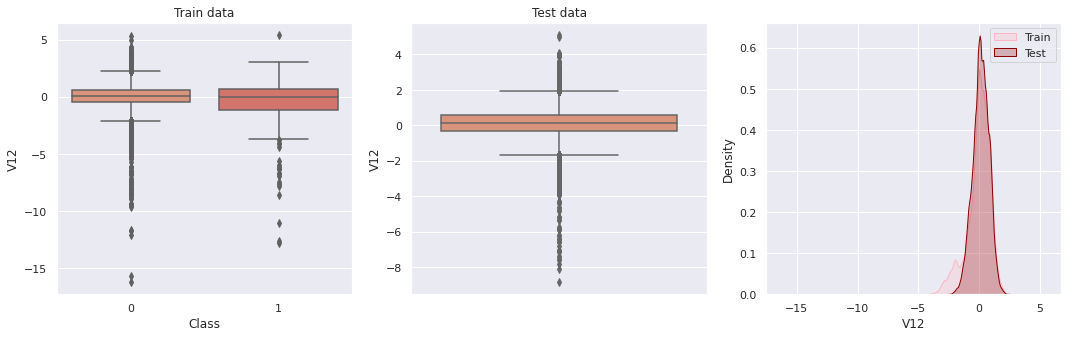

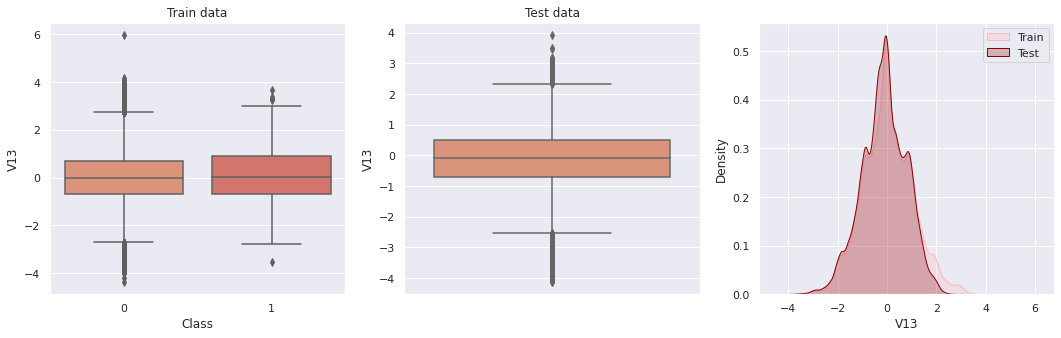

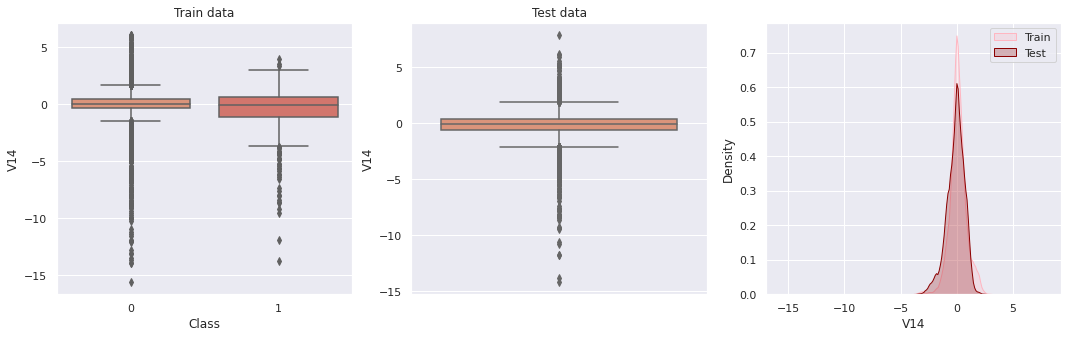

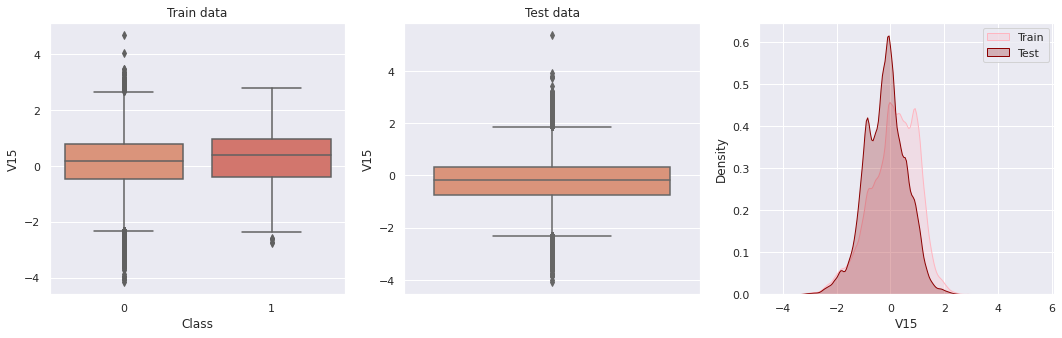

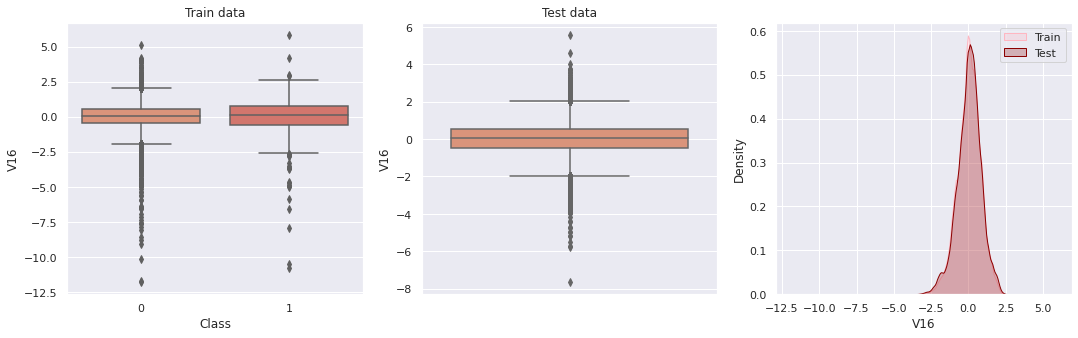

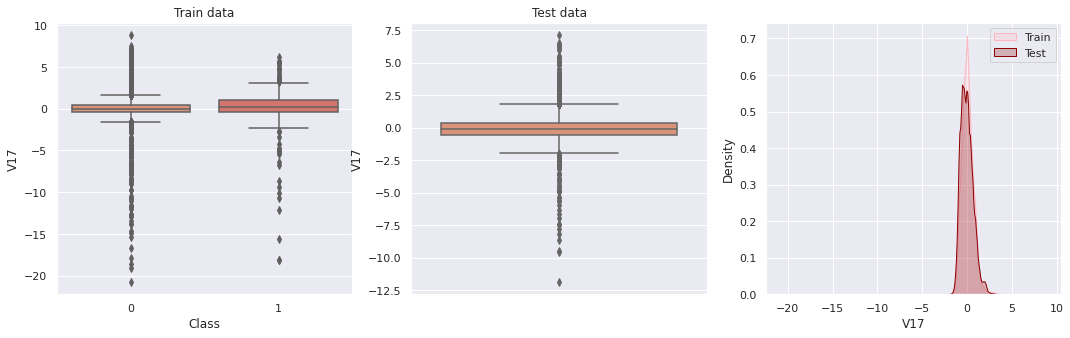

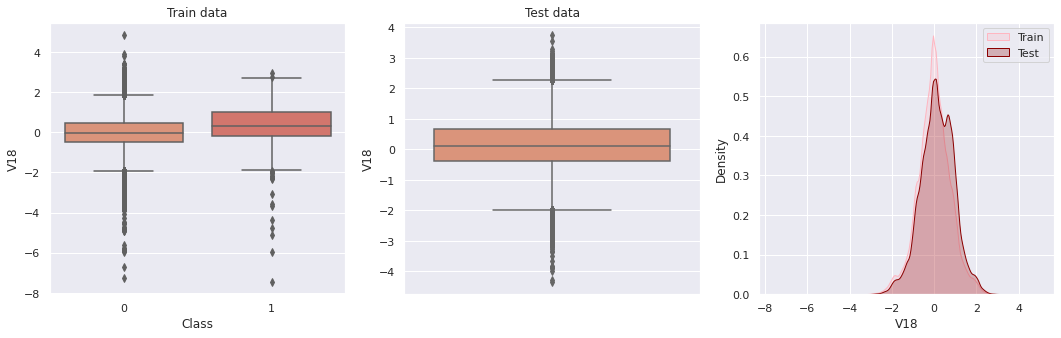

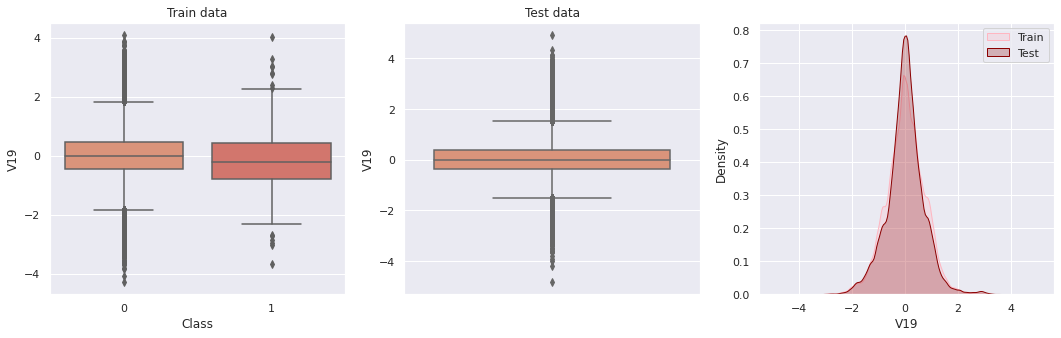

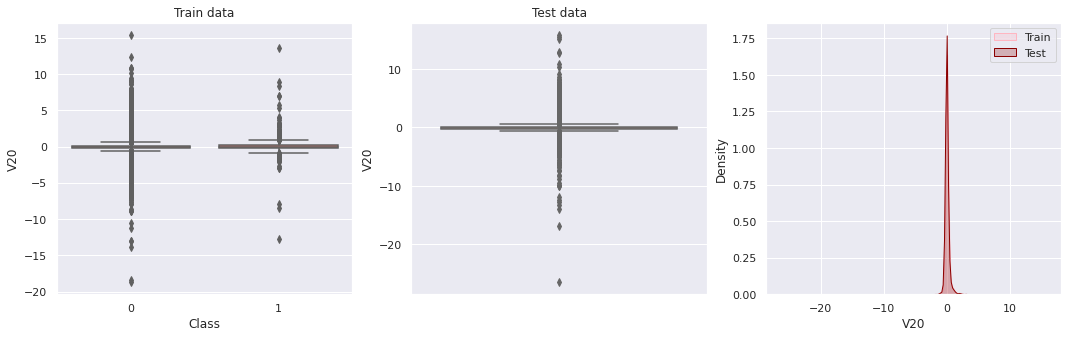

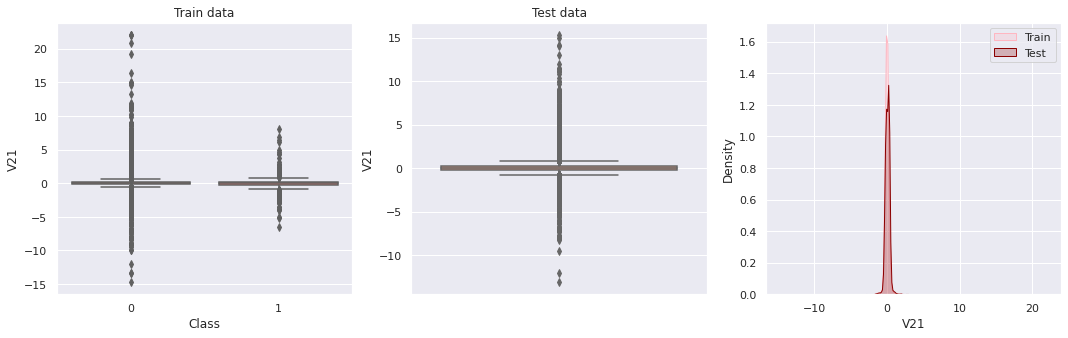

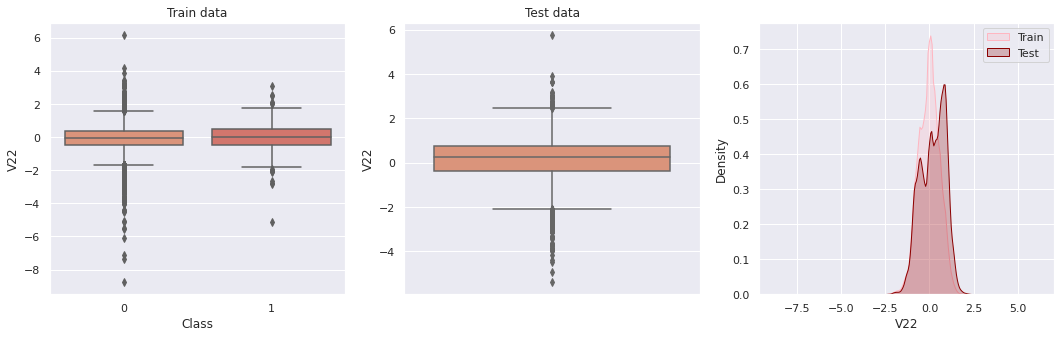

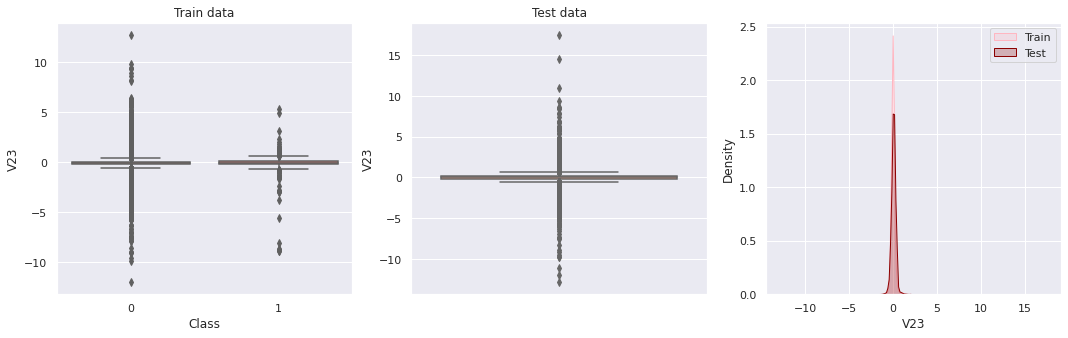

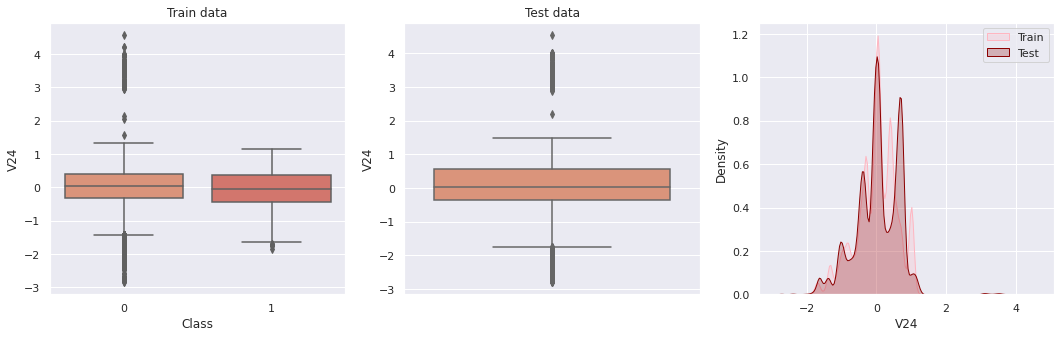

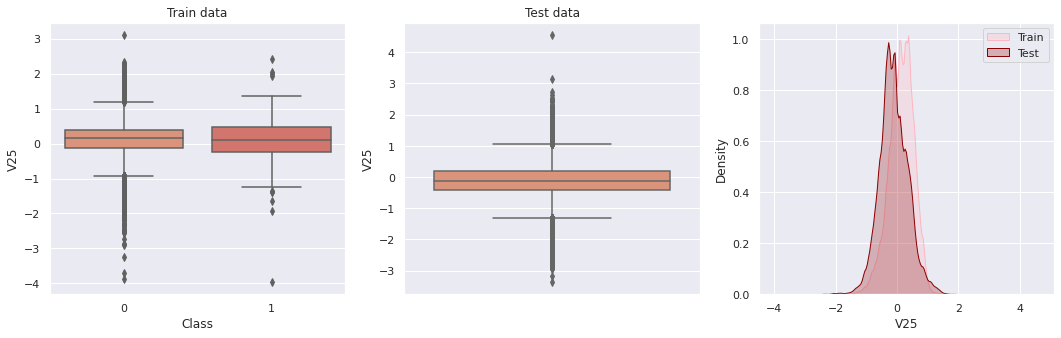

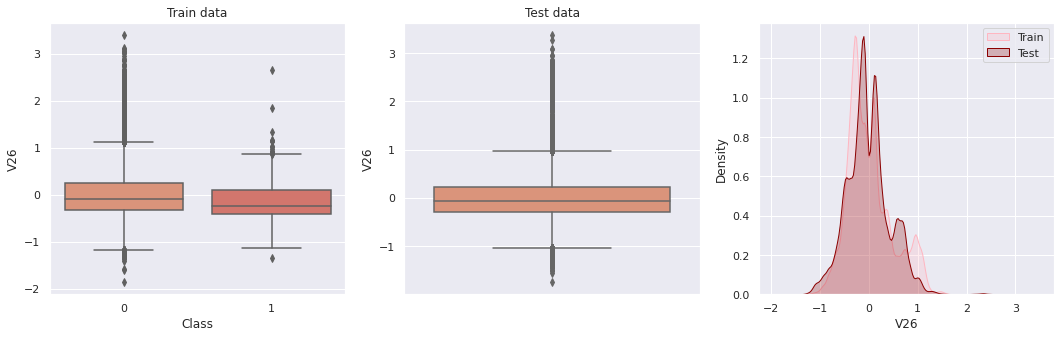

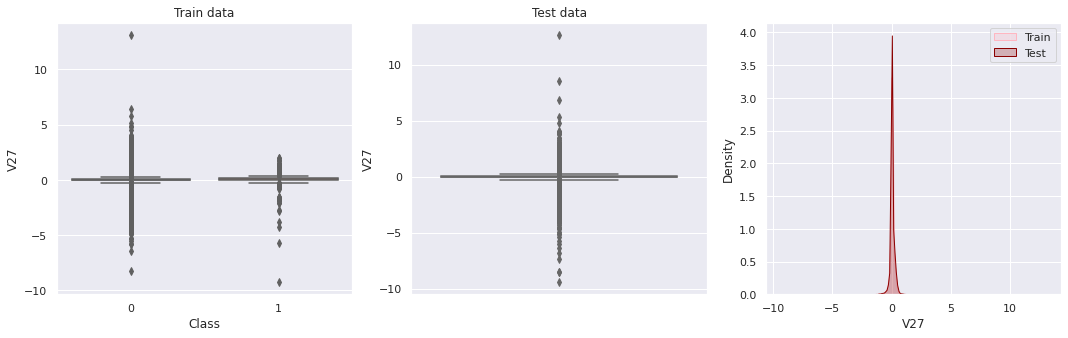

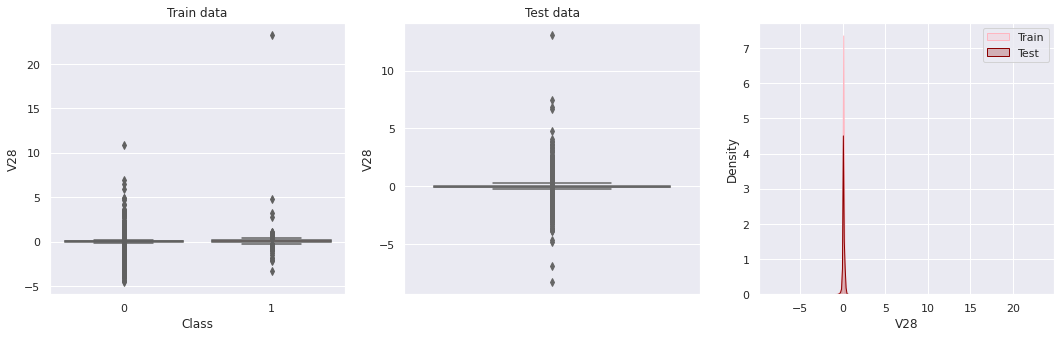

In [19]:
cont_features = ['V1','V2','V3','V4','V5','V6','V7','V8','V9','V10',
                 'V11','V12','V13','V14','V15','V16','V17','V18','V19','V20',
                 'V21','V22','V23','V24','V25','V26','V27','V28']
                 
              
for feature in cont_features:
    fig,axes = plt.subplots(1,3,figsize=(18,5))
    f0 = sns.boxplot(ax=axes[0],x='Class',y=feature, data=df_train);
    f1 = sns.boxplot(ax=axes[1],y=feature, data=df_test)
    f2 = sns.kdeplot(df_train[feature], shade=True,ax=axes[2], color="#FFB6C1", label="Train",fill=True)
    f2 = sns.kdeplot(df_test[feature], shade=True, ax=axes[2], color='#8B0000', label="Test",fill=True)
    f2.legend()
    f0.title.set_text('Train data')
    f1.title.set_text('Test data')

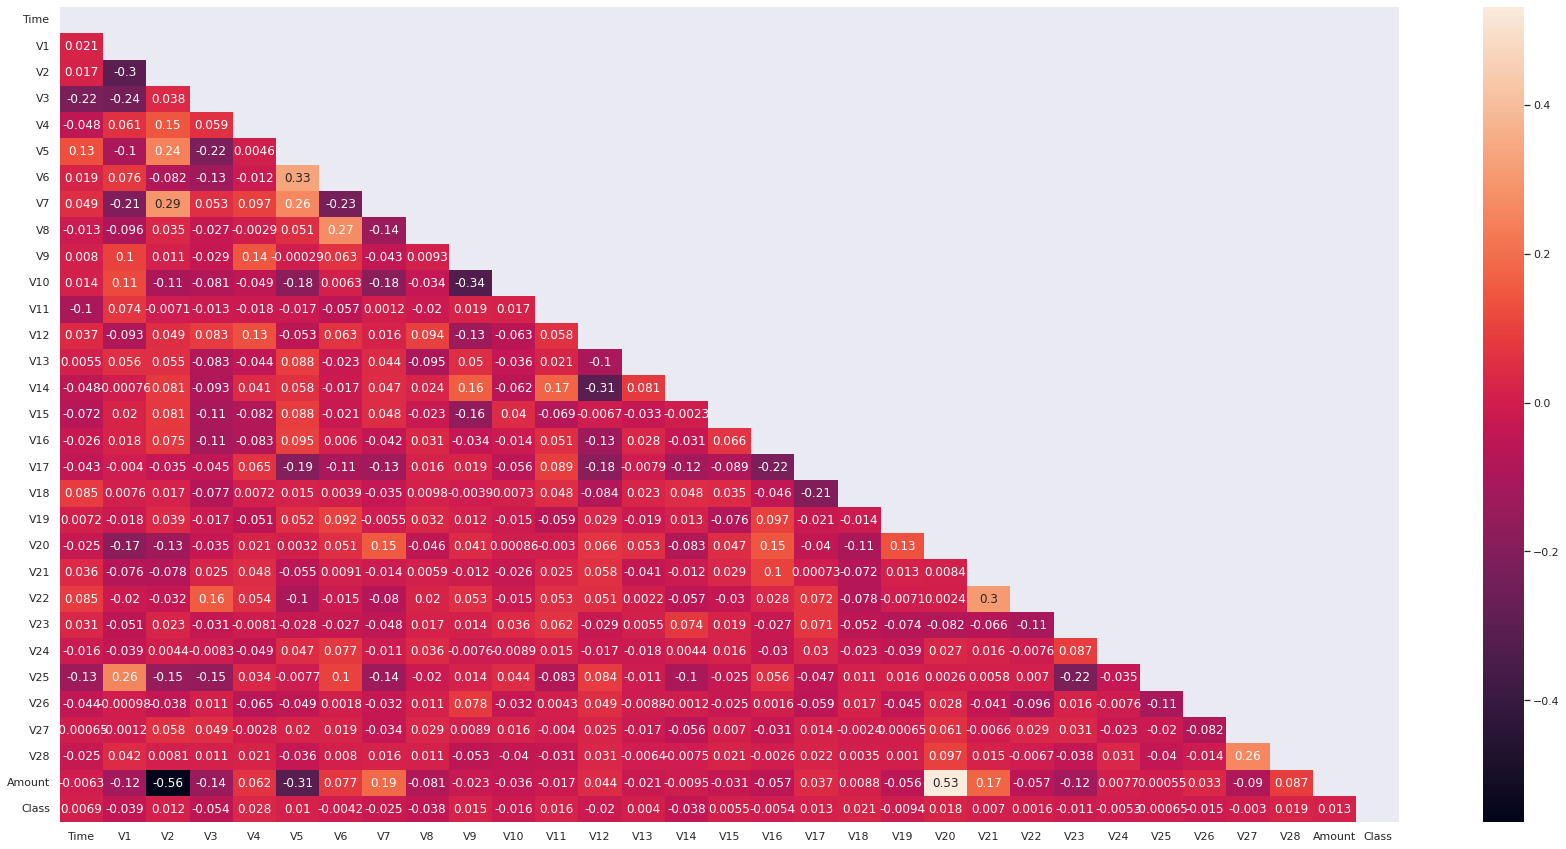

In [20]:
# Heat map
corr = df_train.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.subplots(figsize=(30, 15))
sns.heatmap(corr,mask=mask,annot=True);